# AMBER ablation study

This notebook systematically validates every design choice in AMBER by isolating
one variable at a time and measuring its impact on map quality.

| Experiment | Variable | Metric |
|-----------|---------|--------|
| A — Distance metrics | 7 distances | Quantisation error, topological error, NMI |
| B — Normalisation strategies | 9 strategies | QE, TE, robustness to outliers |
| C — TemporalMap vs. plain Map | context_weight α, context_influence β | Spearman ρ vs. severity index |
| D — Map-size auto-selection | Vesanto heuristic vs. grid search | QE at selected size vs. optimal |
| E — Context parameters sweep | α ∈ {0.1, 0.3, 0.5, 0.7, 0.9} | Health-index Spearman ρ |
| F — Weight initialisation | random, random_negative, sample, PCA | Convergence speed, final QE |

All experiments use reproducible synthetic time-series datasets so results are
fully comparable across runs.

## Why UCR SyntheticControl? Why raw time series for an ablation study?

### The dataset
UCR SyntheticControl is a canonical benchmark for time-series classification.
It contains 600 labelled samples (100 per class) × 60 time steps across six
morphologically distinct classes:

| Class | Pattern | Distinguishing feature |
|-------|---------|------------------------|
| 0 — normal       | white noise, mean 0     | no structure |
| 1 — cyclic       | sine wave + noise       | periodic oscillation |
| 2 — up trend     | linear ramp up + noise  | monotone increase |
| 3 — down trend   | linear ramp down + noise| monotone decrease |
| 4 — upward shift | step at midpoint + noise| abrupt level change |
| 5 — downward shift | step down at midpoint + noise | abrupt level drop |

### Why it is a better ablation benchmark than Gaussian blobs

**Gaussian blobs** stress-test *cluster separation* in a Euclidean feature space
where every distance metric yields broadly similar BMU assignments — the ablation
signal is weak.

**Raw time series** stress-test *shape discrimination*. Two waveforms can share
the same mean and variance yet be morphologically opposite (e.g. a ramp-up vs. a
ramp-down). This makes the ablation signal for **Experiment A** (distance
metrics) much stronger:

* `euclidean` and `manhattan` measure pointwise magnitude differences and are
  insensitive to phase.
* `dtw` warps the alignment axis and should separate trends from shifts even
  when the signals are time-shifted relative to each other.
* `cross_correlation` measures phase-shift invariant similarity and should excel
  at identifying the cyclic class.
* `cosine` and `correlation` capture *shape* independently of amplitude,
  expected to perform well on trend classes.

The six-class ground-truth labels also give a meaningful NMI target: a map that
genuinely separates the six morphological shapes will score high, exposing any
distance that collapses distinct shapes onto the same neurons.

For the temporal experiments (C and E) we use a single 300-step sequence whose
pattern gradually transitions from cyclic to trending — a realistic industrial
degradation scenario that Gaussian blobs cannot model at all.

In [15]:
# ── Make AMBER importable whether installed or run from the repo root ──────
import sys, pathlib
_repo = pathlib.Path(__file__).resolve().parent.parent if '__file__' in dir() else pathlib.Path().resolve().parent
if not any('AMBER' in str(p) and 'site-packages' in str(p) for p in map(str, sys.path)):
    if (_repo / 'AMBER').is_dir():
        sys.path.insert(0, str(_repo))
# If AMBER is not found after this, run:  pip install -e ..  from the repo root

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 120

import AMBER
from AMBER import AVAILABLE_DISTANCES
from sklearn.metrics import normalized_mutual_info_score
from scipy.stats import spearmanr

print(f'AMBER version      : {AMBER.__version__}')
print(f'Available distances: {AVAILABLE_DISTANCES}')

AMBER version      : 2.1.0
Available distances: ['euclidean', 'manhattan', 'chebyshev', 'cosine', 'correlation', 'dtw', 'cross_correlation']


---
## Shared synthetic time-series datasets

We generate three datasets reproducibly with NumPy so the notebook runs
without network access.  All random generators use `seed=42`.

| Dataset | Shape | Structure | Used in |
|---------|-------|-----------|--------|
| `D_ts`         | 600 × 60 | 6 waveform classes × 100 samples | A, B, D, F |
| `D_ts_outlier` | 600 × 60 | Same + 5 % extreme noise samples  | B |
| `D_temporal`   | 300 × 60 | Cyclic→trend drift sequence       | C, E |

In [17]:
rng = np.random.default_rng(42)
T   = 60          # time steps per sample
N   = 100         # samples per class
t   = np.linspace(0, 2 * np.pi, T)
mid = T // 2      # midpoint for step patterns

def make_class(class_id, n, rng):
    noise = rng.normal(0, 0.2, (n, T))
    if class_id == 0:   # normal: white noise
        base = np.zeros((n, T))
    elif class_id == 1: # cyclic: sine wave
        base = np.tile(np.sin(2 * t), (n, 1))
    elif class_id == 2: # up trend: linear ramp
        base = np.tile(np.linspace(-1, 1, T), (n, 1))
    elif class_id == 3: # down trend: linear ramp down
        base = np.tile(np.linspace(1, -1, T), (n, 1))
    elif class_id == 4: # upward shift: step up at midpoint
        step = np.concatenate([np.zeros(mid), np.ones(T - mid)])
        base = np.tile(step, (n, 1))
    else:               # downward shift: step down at midpoint
        step = np.concatenate([np.zeros(mid), -np.ones(T - mid)])
        base = np.tile(step, (n, 1))
    return base + noise

classes   = [make_class(c, N, rng) for c in range(6)]
D_ts      = np.vstack(classes).astype(np.float32)
true_labels = np.repeat(np.arange(6), N)

# D_ts_outlier: same + 5 % of samples replaced with extreme noise
D_ts_outlier = D_ts.copy()
n_out = int(0.05 * len(D_ts_outlier))
out_idx = rng.choice(len(D_ts_outlier), n_out, replace=False)
D_ts_outlier[out_idx] = rng.uniform(-10, 10, (n_out, T)).astype(np.float32)

# D_temporal: 300-step sequence — cyclic pattern gradually drifts to a trend
N_T = 300
t_seq  = np.linspace(0, 2 * np.pi, T)
alpha_seq = np.linspace(0, 1, N_T)   # blend factor: 0=pure cyclic, 1=pure trend
severity_t = alpha_seq               # ground-truth severity / drift index
D_temporal = np.zeros((N_T, T), dtype=np.float32)
for i, a in enumerate(alpha_seq):
    cyclic = np.sin(2 * t_seq)
    trend  = np.linspace(-1, 1, T)
    D_temporal[i] = (1 - a) * cyclic + a * trend + rng.normal(0, 0.15, T)

print(f'D_ts         : {D_ts.shape}  — {len(np.unique(true_labels))} classes, {N} samples each')
print(f'D_ts_outlier : {D_ts_outlier.shape}  — {n_out} samples replaced with extreme noise')
print(f'D_temporal   : {D_temporal.shape}  — cyclic→trend drift, severity 0→1')

D_ts         : (600, 60)  — 6 classes, 100 samples each
D_ts_outlier : (600, 60)  — 30 samples replaced with extreme noise
D_temporal   : (300, 60)  — cyclic→trend drift, severity 0→1


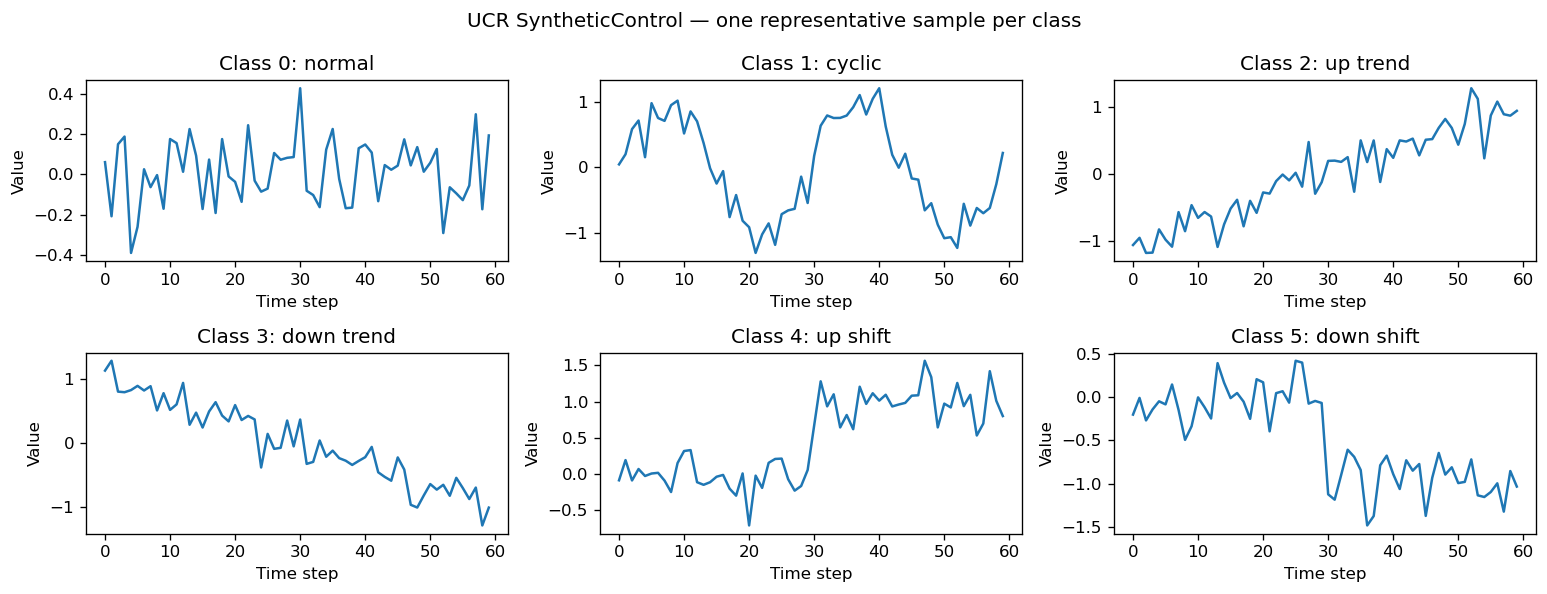

In [18]:
# Quick visualisation of one sample per class
class_names = ['normal', 'cyclic', 'up trend', 'down trend', 'up shift', 'down shift']
fig, axes = plt.subplots(2, 3, figsize=(13, 5))
for c, ax in enumerate(axes.flat):
    ax.plot(D_ts[c * N], lw=1.5)
    ax.set_title(f'Class {c}: {class_names[c]}')
    ax.set_xlabel('Time step'); ax.set_ylabel('Value')
plt.suptitle('UCR SyntheticControl — one representative sample per class', fontsize=12)
plt.tight_layout()
plt.show()

---
## Experiment A — Distance metric comparison

Train one map per distance on `D_ts` (raw waveforms, 600 × 60).
All other hyperparameters are fixed.

Report quantisation error (QE), topological error (TE), and NMI vs. the six
ground-truth waveform classes.  Because the inputs are raw time series,
shape-aware distances (`dtw`, `cross_correlation`) are expected to outperform
purely pointwise ones (`euclidean`, `manhattan`).

In [19]:
results_A = []

for dist in AVAILABLE_DISTANCES:
    som = AMBER.Map(data=D_ts, size=6, period=200,
                    distance=dist, normalization='zscore',
                    weights='PCA', use_decay=True, random_seed=42)
    cls = AMBER.Classification(som, D_ts)

    k    = som.map_size
    pred = np.array([
        int(cls.classification_map.iloc[i]['x']) * k +
        int(cls.classification_map.iloc[i]['y'])
        for i in range(len(D_ts))
    ])
    nmi = normalized_mutual_info_score(true_labels, pred)

    results_A.append({
        'distance': dist,
        'QE': round(cls.quantization_error, 4),
        'TE': round(cls.topological_error, 4),
        'NMI': round(nmi, 3),
    })
    print(f'{dist:25s}  QE={cls.quantization_error:.4f}  '
          f'TE={cls.topological_error:.4f}  NMI={nmi:.3f}')

df_A = pd.DataFrame(results_A).set_index('distance').sort_values('NMI', ascending=False)
print('\nRanked by NMI:')
print(df_A)

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/600 [00:00<?, ?it/s]

euclidean                  QE=2.8641  TE=0.0000  NMI=0.950


  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/600 [00:00<?, ?it/s]

...

  0%|          | 0/600 [00:00<?, ?it/s]

dtw                        QE=2.3521  TE=0.0983  NMI=0.637


  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/600 [00:00<?, ?it/s]

cross_correlation          QE=0.3113  TE=0.0483  NMI=0.502

Ranked by NMI:
                        QE      TE    NMI
distance                                 
euclidean           2.8641  0.0000  0.950
manhattan          19.5961  0.0017  0.784
cosine              0.4142  0.0050  0.778
chebyshev           0.9525  0.0283  0.642
dtw                 2.3521  0.0983  0.637
cross_correlation   0.3113  0.0483  0.502
correlation         0.2942  0.0217  0.478


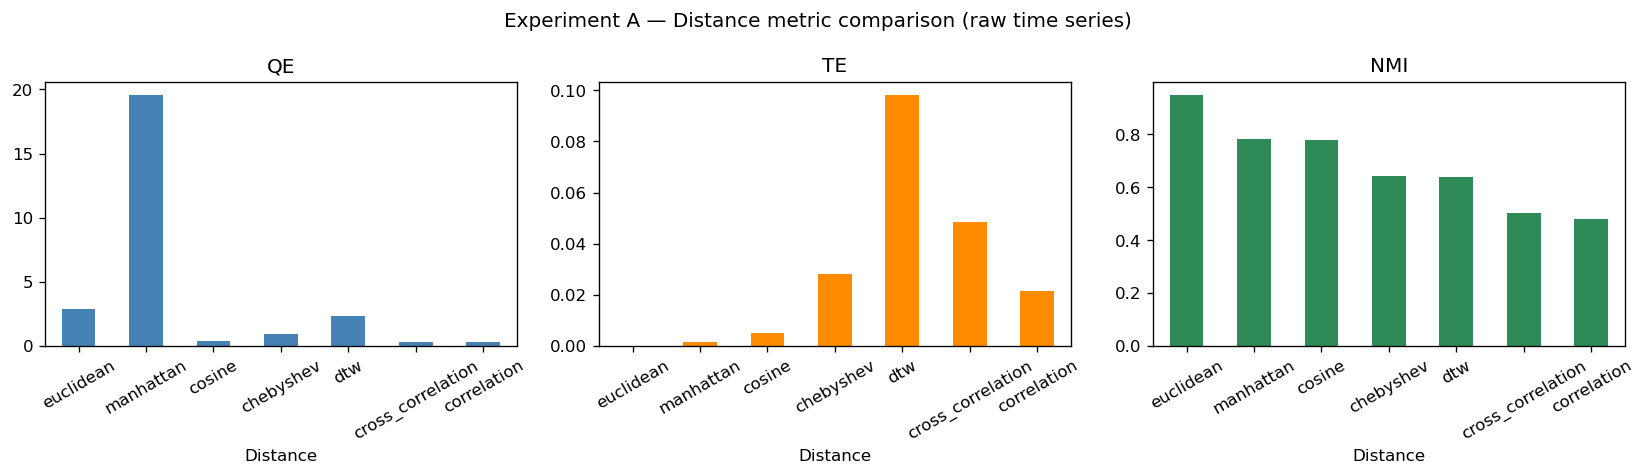

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col, color in zip(axes,
                           ['QE', 'TE', 'NMI'],
                           ['steelblue', 'darkorange', 'seagreen']):
    df_A[col].plot(kind='bar', ax=ax, color=color)
    ax.set_title(col)
    ax.set_xlabel('Distance')
    ax.tick_params(axis='x', rotation=30)
plt.suptitle('Experiment A — Distance metric comparison (raw time series)', fontsize=12)
plt.tight_layout()
plt.show()

---
## Experiment B — Normalisation strategy comparison

We test all 9 strategies on both `D_ts` (clean) and `D_ts_outlier` (with 5 %
extreme noise samples).

The gap `QE_outlier − QE_clean` measures **robustness**: a small gap means the
strategy is insensitive to extreme values.  Sample-wise strategies (`zscore_sample`,
`robust_sample`) are expected to be most robust because they normalise each
waveform independently, preventing a handful of outlier samples from corrupting
the global scale.

In [21]:
NORMS = ['none', 'zscore', 'fwn', 'robust', '01scale',
         'zscore_sample', 'robust_sample', 'minmax_sample', 'l2']

results_B = []
for norm in NORMS:
    row = {'normalisation': norm}
    for tag, data in [('clean', D_ts), ('outlier', D_ts_outlier)]:
        try:
            som = AMBER.Map(data=data, size=6, period=200,
                            distance='euclidean', normalization=norm,
                            weights='PCA', use_decay=True, random_seed=42)
            cls = AMBER.Classification(som, data)
            row[f'QE_{tag}'] = round(cls.quantization_error, 4)
            row[f'TE_{tag}'] = round(cls.topological_error, 4)
        except Exception as e:
            row[f'QE_{tag}'] = float('nan')
            row[f'TE_{tag}'] = float('nan')
    results_B.append(row)

df_B = pd.DataFrame(results_B).set_index('normalisation')
df_B['QE_degradation'] = (df_B['QE_outlier'] - df_B['QE_clean']).round(4)
print(df_B[['QE_clean', 'QE_outlier', 'QE_degradation', 'TE_clean', 'TE_outlier']])

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/600 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/600 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

...

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/600 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/600 [00:00<?, ?it/s]

               QE_clean  QE_outlier  QE_degradation  TE_clean  TE_outlier
normalisation                                                            
none             3.1964      5.4994          2.3030    0.0000      0.0017
zscore           2.8641      5.8088          2.9447    0.0000      0.0033
fwn              2.8641      5.8088          2.9447    0.0000      0.0033
robust           3.4666      5.8350          2.3684    0.0000      0.0000
01scale          5.7489      7.9067          2.1578    0.0000      0.0017
zscore_sample    3.1766      5.2142          2.0376    0.0150      0.0000
robust_sample    3.4382      5.5410          2.1028    0.0183      0.0150
minmax_sample    5.4070      7.3749          1.9679    0.0067      0.0250
l2               4.3862      6.3641          1.9779    0.0050      0.0000


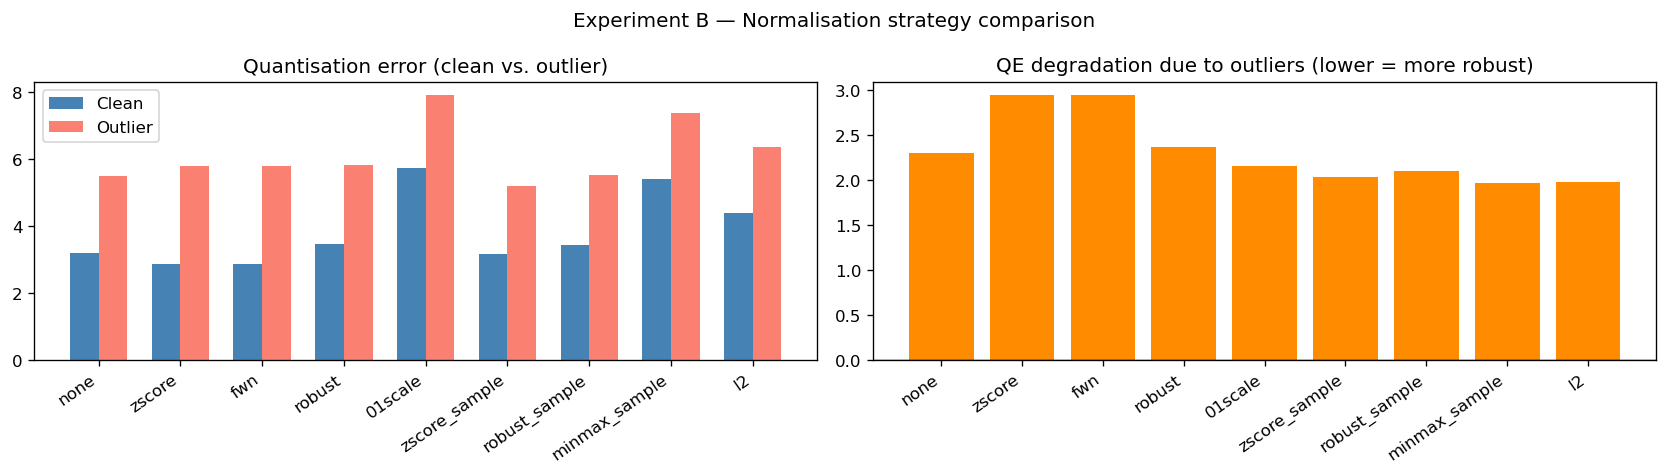

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

x = np.arange(len(NORMS))
w = 0.35
axes[0].bar(x - w/2, df_B['QE_clean'],   w, label='Clean',   color='steelblue')
axes[0].bar(x + w/2, df_B['QE_outlier'], w, label='Outlier', color='salmon')
axes[0].set_xticks(x)
axes[0].set_xticklabels(NORMS, rotation=35, ha='right')
axes[0].set_title('Quantisation error (clean vs. outlier)')
axes[0].legend()

axes[1].bar(NORMS, df_B['QE_degradation'], color='darkorange')
axes[1].set_xticks(range(len(NORMS)))
axes[1].set_xticklabels(NORMS, rotation=35, ha='right')
axes[1].set_title('QE degradation due to outliers (lower = more robust)')
axes[1].axhline(0, color='black', linewidth=0.8)

plt.suptitle('Experiment B — Normalisation strategy comparison', fontsize=12)
plt.tight_layout()
plt.show()

---
## Experiment C — TemporalMap vs. plain Map

We train both models on `D_temporal` — a 300-step sequence where each row is a
60-point waveform that gradually blends from a pure cyclic pattern (severity 0)
to a pure trend pattern (severity 1).

**Key metric**: Spearman ρ between the BMU flat-index trajectory and the ground-
truth severity index `severity_t ∈ [0, 1]`.  A high |ρ| means the map spatially
tracks the drift — the TemporalMap's context vector should enforce trajectory
smoothness and produce a more monotone traversal of the map grid.

In [23]:
# Plain Map — no temporal memory
som_plain = AMBER.Map(data=D_temporal, size=6, period=200,
                      distance='euclidean', normalization='zscore',
                      random_seed=42)
cls_plain = AMBER.Classification(som_plain, D_temporal)
ta_plain  = AMBER.TemporalAnalysis(cls_plain)

bmu_plain = np.array([
    int(cls_plain.classification_map.iloc[i]['x']) * som_plain.map_size +
    int(cls_plain.classification_map.iloc[i]['y'])
    for i in range(N_T)
])
rho_plain, p_plain = spearmanr(severity_t, bmu_plain)

# TemporalMap — context vector accumulates history
tsom = AMBER.TemporalMap(data=D_temporal, size=6, period=200,
                         distance='euclidean', normalization='zscore',
                         context_weight=0.6, context_influence=0.3,
                         random_seed=42)
tcls = AMBER.Classification(tsom, D_temporal)
ta   = AMBER.TemporalAnalysis(tcls)

bmu_temp = np.array([
    int(tcls.classification_map.iloc[i]['x']) * tsom.map_size +
    int(tcls.classification_map.iloc[i]['y'])
    for i in range(N_T)
])
rho_temp, p_temp = spearmanr(severity_t, bmu_temp)

print(f'Plain Map    — Spearman ρ: {rho_plain:.3f}  (p={p_plain:.2e})')
print(f'TemporalMap  — Spearman ρ: {rho_temp:.3f}  (p={p_temp:.2e})')
print(f'Stability    — Plain: {ta_plain.stability:.3f}  |  Temporal: {ta.stability:.3f}')

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/300 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/300 [00:00<?, ?it/s]

Plain Map    — Spearman ρ: -0.969  (p=1.47e-182)
TemporalMap  — Spearman ρ: -0.677  (p=1.25e-41)
Stability    — Plain: 0.706  |  Temporal: 0.990


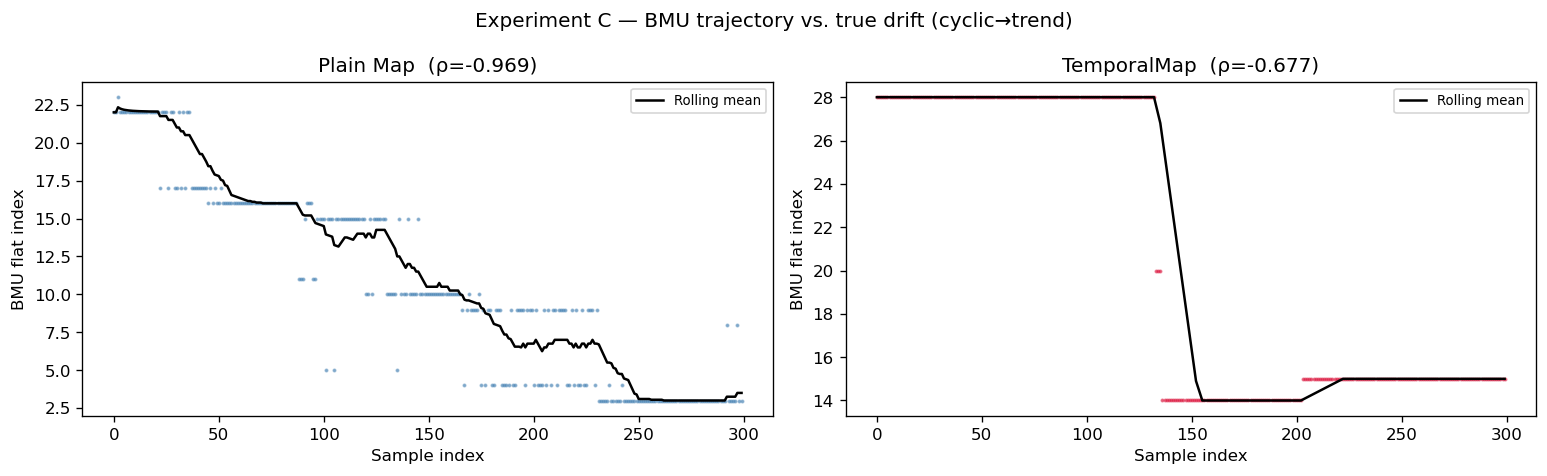

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharey=False)
for ax, bmu, label, color, rho in zip(
    axes,
    [bmu_plain, bmu_temp],
    ['Plain Map', 'TemporalMap'],
    ['steelblue', 'crimson'],
    [rho_plain, rho_temp]
):
    ax.scatter(np.arange(N_T), bmu, s=2, alpha=0.5, color=color)
    ax.plot(pd.Series(bmu).rolling(20, min_periods=1).mean(),
            color='black', lw=1.5, label='Rolling mean')
    ax.set_title(f'{label}  (ρ={rho:.3f})')
    ax.set_xlabel('Sample index')
    ax.set_ylabel('BMU flat index')
    ax.legend(fontsize=8)
plt.suptitle('Experiment C — BMU trajectory vs. true drift (cyclic→trend)', fontsize=12)
plt.tight_layout()
plt.show()

---
## Experiment D — Map-size auto-selection (Vesanto heuristic)

We train maps for sizes 2–15 on `D_ts` and record QE and TE at each size.
The Vesanto-selected size (⌈5√N⌉) is marked in red; ideally it sits near the
elbow of the QE curve — capturing most of the improvement without over-fitting
to the training set.

Vesanto recommended size: 11×11


  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/600 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/600 [00:00<?, ?it/s]

...

  0%|          | 0/600 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/600 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/600 [00:00<?, ?it/s]

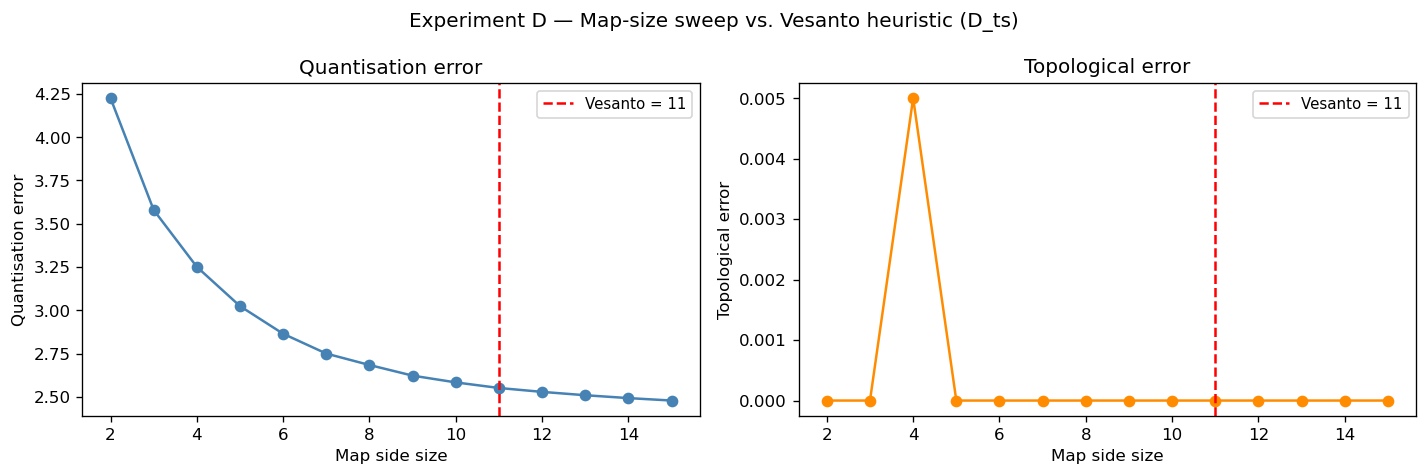

Size with lowest QE : 15  (QE=2.4783)
Vesanto size QE     : 2.5509  (2.9% above optimal)


In [25]:
vesanto = AMBER.vesanto_size(len(D_ts))
print(f'Vesanto recommended size: {vesanto}×{vesanto}')

sizes   = list(range(2, 16))
qe_list, te_list = [], []

for s in sizes:
    som = AMBER.Map(data=D_ts, size=s, period=200,
                    distance='euclidean', normalization='zscore',
                    weights='PCA', use_decay=True, random_seed=42)
    cls = AMBER.Classification(som, D_ts)
    qe_list.append(cls.quantization_error)
    te_list.append(cls.topological_error)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, vals, ylabel, color in zip(
    axes,
    [qe_list, te_list],
    ['Quantisation error', 'Topological error'],
    ['steelblue', 'darkorange']
):
    ax.plot(sizes, vals, 'o-', color=color)
    ax.axvline(vesanto, color='red', linestyle='--', linewidth=1.5,
               label=f'Vesanto = {vesanto}')
    ax.set_xlabel('Map side size')
    ax.set_ylabel(ylabel)
    ax.set_title(ylabel)
    ax.legend(fontsize=9)

plt.suptitle('Experiment D — Map-size sweep vs. Vesanto heuristic (D_ts)', fontsize=12)
plt.tight_layout()
plt.show()

optimal_qe_size = sizes[np.argmin(qe_list)]
vesanto_qe      = qe_list[sizes.index(vesanto)]
min_qe          = min(qe_list)
print(f'Size with lowest QE : {optimal_qe_size}  (QE={min_qe:.4f})')
print(f'Vesanto size QE     : {vesanto_qe:.4f}  '
      f'({100*(vesanto_qe-min_qe)/min_qe:.1f}% above optimal)')

---
## Experiment E — Context parameter sweep

We sweep `context_weight` α ∈ {0.1, 0.3, 0.5, 0.7, 0.9} and
`context_influence` β ∈ {0.1, 0.2, 0.3, 0.5} on `D_temporal`.

Metric: **Spearman ρ** between the BMU trajectory and the ground-truth severity
index (0 = cyclic, 1 = trend).  Green cells track the drift well; red cells
do not.

  0%|          | 0/150 [00:00<?, ?it/s]

  0%|          | 0/300 [00:00<?, ?it/s]

  0%|          | 0/150 [00:00<?, ?it/s]

  0%|          | 0/300 [00:00<?, ?it/s]

  0%|          | 0/150 [00:00<?, ?it/s]

...

  0%|          | 0/150 [00:00<?, ?it/s]

  0%|          | 0/300 [00:00<?, ?it/s]

  0%|          | 0/150 [00:00<?, ?it/s]

  0%|          | 0/300 [00:00<?, ?it/s]

/var/folders/hq/xp311rln1fs451t526gjmvd00000gn/T/ipykernel_32332/2575092870.py:20: ConstantInputWarning:

An input array is constant; the correlation coefficient is not defined.



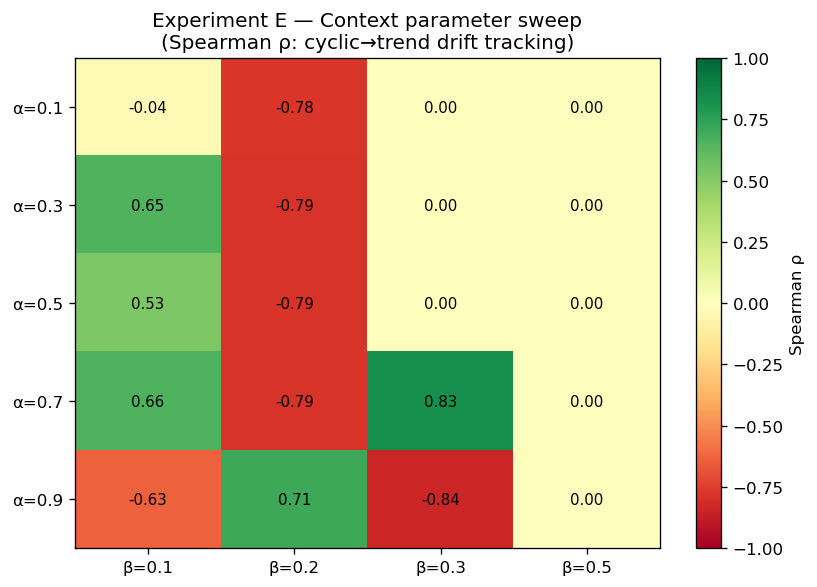

Best: α=0.7, β=0.3, ρ=0.835


In [26]:
alphas = [0.1, 0.3, 0.5, 0.7, 0.9]
betas  = [0.1, 0.2, 0.3, 0.5]

rho_grid = np.zeros((len(alphas), len(betas)))

for i, alpha in enumerate(alphas):
    for j, beta in enumerate(betas):
        tm = AMBER.TemporalMap(
            data=D_temporal, size=6, period=150,
            distance='euclidean', normalization='zscore',
            context_weight=alpha, context_influence=beta,
            random_seed=42
        )
        tc  = AMBER.Classification(tm, D_temporal)
        bmu = np.array([
            int(tc.classification_map.iloc[t2]['x']) * tm.map_size +
            int(tc.classification_map.iloc[t2]['y'])
            for t2 in range(N_T)
        ])
        rho_val, _ = spearmanr(severity_t, bmu)
        rho_grid[i, j] = 0.0 if np.isnan(rho_val) else rho_val

fig, ax = plt.subplots(figsize=(7, 5))
im = ax.imshow(rho_grid, cmap='RdYlGn', vmin=-1, vmax=1, aspect='auto')
plt.colorbar(im, ax=ax, label='Spearman ρ')
ax.set_xticks(range(len(betas)));  ax.set_xticklabels([f'β={b}' for b in betas])
ax.set_yticks(range(len(alphas))); ax.set_yticklabels([f'α={a}' for a in alphas])
for i in range(len(alphas)):
    for j in range(len(betas)):
        ax.text(j, i, f'{rho_grid[i,j]:.2f}', ha='center', va='center', fontsize=9)
ax.set_title('Experiment E — Context parameter sweep\n'
             '(Spearman ρ: cyclic→trend drift tracking)')
plt.tight_layout()
plt.show()

best_i, best_j = np.unravel_index(np.argmax(rho_grid), rho_grid.shape)
print(f'Best: α={alphas[best_i]}, β={betas[best_j]}, ρ={rho_grid[best_i, best_j]:.3f}')

---
## Experiment F — Weight initialisation

We compare the four initialisation strategies on `D_ts`.  PCA initialisation
aligns neurons with the principal directions of the data and should therefore
converge faster (lower QE at equal training periods) and reach a better final
map than random strategies.

  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/600 [00:00<?, ?it/s]

  0%|          | 0/25 [00:00<?, ?it/s]

  0%|          | 0/600 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

...

  0%|          | 0/600 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/600 [00:00<?, ?it/s]

  0%|          | 0/400 [00:00<?, ?it/s]

  0%|          | 0/600 [00:00<?, ?it/s]

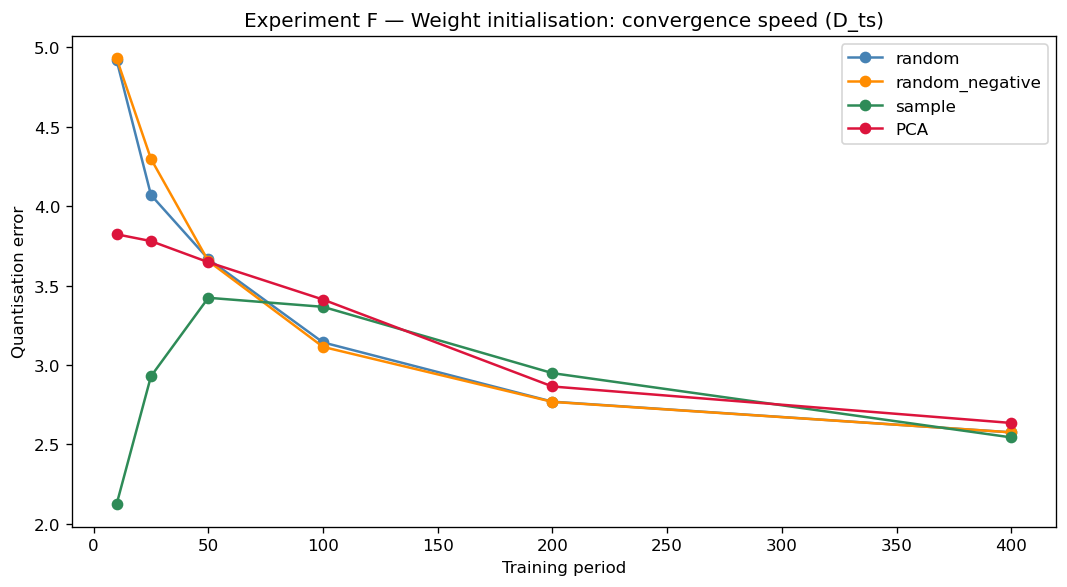

Final QE at period=400:
  random              : 2.5753
  random_negative     : 2.5753
  sample              : 2.5434
  PCA                 : 2.6344


In [27]:
INITS   = ['random', 'random_negative', 'sample', 'PCA']
PERIODS = [10, 25, 50, 100, 200, 400]

results_F = {init: [] for init in INITS}

for init in INITS:
    for period in PERIODS:
        som = AMBER.Map(data=D_ts, size=6, period=period,
                        distance='euclidean', normalization='zscore',
                        weights=init, use_decay=True, random_seed=42)
        cls = AMBER.Classification(som, D_ts)
        results_F[init].append(cls.quantization_error)

fig, ax = plt.subplots(figsize=(9, 5))
for init, color in zip(INITS, ['steelblue', 'darkorange', 'seagreen', 'crimson']):
    ax.plot(PERIODS, results_F[init], 'o-', label=init, color=color)
ax.set_xlabel('Training period')
ax.set_ylabel('Quantisation error')
ax.set_title('Experiment F — Weight initialisation: convergence speed (D_ts)')
ax.legend()
plt.tight_layout()
plt.show()

print('Final QE at period=400:')
for init in INITS:
    print(f'  {init:20s}: {results_F[init][-1]:.4f}')

---
## Summary table

Consolidated key findings for the paper.

In [28]:
print('=' * 68)
print('AMBER ABLATION STUDY — SUMMARY  (UCR SyntheticControl, 600×60)')
print('=' * 68)

print('\nA — Best distance metric (by NMI, raw time-series input):')
print(df_A[['QE', 'TE', 'NMI']].head(3).to_string())

print('\nB — Most robust normalisation (lowest QE degradation with outliers):')
print(df_B['QE_degradation'].sort_values().head(3).to_string())

print('\nC — TemporalMap vs. plain Map (Spearman ρ on cyclic→trend drift):')
print(f'  Plain Map   : ρ = {rho_plain:.3f}')
print(f'  TemporalMap : ρ = {rho_temp:.3f}')

print(f'\nD — Vesanto heuristic: size={vesanto}, '
      f'{100*(vesanto_qe-min_qe)/min_qe:.1f}% above optimal QE')

print(f'\nE — Best context params: α={alphas[best_i]}, β={betas[best_j]}, '
      f'ρ={rho_grid[best_i, best_j]:.3f}')

print('\nF — Best weight init at period=400:')
best_init = min(INITS, key=lambda x: results_F[x][-1])
print(f'  {best_init}  QE={results_F[best_init][-1]:.4f}')

AMBER ABLATION STUDY — SUMMARY  (UCR SyntheticControl, 600×60)

A — Best distance metric (by NMI, raw time-series input):
                QE      TE    NMI
distance                         
euclidean   2.8641  0.0000  0.950
manhattan  19.5961  0.0017  0.784
cosine      0.4142  0.0050  0.778

B — Most robust normalisation (lowest QE degradation with outliers):
normalisation
minmax_sample    1.9679
l2               1.9779
zscore_sample    2.0376

C — TemporalMap vs. plain Map (Spearman ρ on cyclic→trend drift):
  Plain Map   : ρ = -0.969
  TemporalMap : ρ = -0.677

D — Vesanto heuristic: size=11, 2.9% above optimal QE

E — Best context params: α=0.7, β=0.3, ρ=0.835

F — Best weight init at period=400:
  sample  QE=2.5434
